To begin copy this notebook to your own drive:

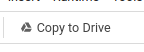


### Submission Instructions:
1. **Download the notebook** (in the menubar, select File$\rightarrow$Download .ipynb)
2. **Upload the downloaded notebook (.ipynb file) to your repository**.


Make sure you fill in any place that says `YOUR CODE HERE`, and all the cells include their outputs

Note: To use a GPU, do the following: Runtime$\rightarrow$Change runtime type$\rightarrow$ GPU

In [1]:
!pip install datasets
!pip install transformers
!pip install nltk
!pip install evaluate
%pip install accelerate


Looking in indexes: https://pypi.apple.com/simple
Looking in indexes: https://pypi.apple.com/simple
Looking in indexes: https://pypi.apple.com/simple
Looking in indexes: https://pypi.apple.com/simple
Looking in indexes: https://pypi.apple.com/simple
Note: you may need to restart the kernel to use updated packages.


In [2]:
import nltk
nltk.download('punkt_tab')
## If you're usig older version of nltk, you night need to use this lin instead:
# nltk.download('punkt')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/galbarak/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [3]:
# The assignment zip includes 2 files you need to use:
# 'glove.npy' and 'vocab.json'.
# you can upload the directly to this session storage, using the "files" button on the left menu,
# and then the "upload" button on the top of the sidebar. This upload is only valid for each session,
# so if you restart the session you'll neeed to upload the files again

# If you prefer, You can download the files directly to the sessio using these three lines:
# import gdown
# gdown.download('https://drive.google.com/uc?export=download&id=1PFOG06NEsTL6VieKQjMk1oNzyzcUtiWn', 'glove.npy', quiet=False)
# gdown.download('https://drive.google.com/uc?export=download&id=1-3SxpirQjmX-RCRyRjKdP2L7G_tNgp00', 'vocab.json', quiet=False)

In [4]:
import numpy as np
from datasets import load_dataset

raw_datasets = load_dataset("imdb")

/Users/galbarak/Desktop/NLP/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
from nltk.tokenize import word_tokenize
import json

with open("vocab.json") as f:
  vocab = json.load(f)

def tokenize_function(example):
  sentences = [x.lower() for x in example['text']]
  tokenized_sentences = [word_tokenize(x) for x in sentences]
  tokenized_idx = [[vocab[word] if word in vocab else vocab["unk"] for word in x] for x in tokenized_sentences]
  max_size = max([len(x) for x in tokenized_idx])
  final_tokenized_idx = tokenized_idx

  return {"labels":example['label'],'input_ids':final_tokenized_idx}

In [6]:
small_train_dataset = raw_datasets['train'].shuffle(seed=42).map(tokenize_function,batched=True)
small_eval_dataset = raw_datasets['test'].shuffle(seed=42).map(tokenize_function,batched=True)

In [7]:
def pad_sequence_to_length(
    sequence,
    desired_length: int,
    default_value = lambda: 0,
    padding_on_right: bool = True,
):
    sequence = list(sequence)
    # Truncates the sequence to the desired length.
    if padding_on_right:
        padded_sequence = sequence[:desired_length]
    else:
        padded_sequence = sequence[-desired_length:]
    # Continues to pad with default_value() until we reach the desired length.
    pad_length = desired_length - len(padded_sequence)
    # This just creates the default value once, so if it's a list, and if it gets mutated
    # later, it could cause subtle bugs. But the risk there is low, and this is much faster.
    values_to_pad = [default_value()] * pad_length
    if padding_on_right:
        padded_sequence = padded_sequence + values_to_pad
    else:
        padded_sequence = values_to_pad + padded_sequence
    return padded_sequence

In [8]:
from evaluate import load
metric = load("accuracy")

### If you're using older versions, use:
# metric = dataset.load_metric("accuracy")

def compute_metrics(eval_pred):
    logits = eval_pred.predictions
    labels = eval_pred.label_ids
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

In [9]:
from dataclasses import dataclass

@dataclass
class DataCollatorWithPadding:

  def __call__(self, features):
    features_dict={}
    if "labels" in features[0]:

      features_dict["labels"] = torch.tensor([x.pop("labels") for x in features]).long()

    input_ids = [x.pop("input_ids") for x in features]
    max_len = max(len(x) for x in input_ids)
    masks = [[1]*len(x) for x in input_ids]

    features_dict["input_ids"] = torch.tensor([pad_sequence_to_length(x,max_len) for x in input_ids]).long()
    features_dict["attention_masks"] = torch.tensor([pad_sequence_to_length(x,max_len) for x in masks]).long()

    return features_dict


## SECTION A - DAN implentation

In [10]:
from torch import nn
import torch
#Use nn.Sequential and nn.Linear for the network, and nn.CrossEntropyLoss for the loss.
#Make sure that the final layer has output dimension of size 2.
class DAN(nn.Module):
  def __init__(self): # YOU ARE ALSO ALLOWED TO ADD PARAMETER TO THE __INIT__
          super().__init__()
          self.num_labels = 2
          self.embeddings = nn.Embedding.from_pretrained(torch.FloatTensor(np.load("glove.npy")))
          # YOUR CODE HERE
          embed_dim = self.embeddings.embedding_dim
          hidden_dim = 300
          self.classifier = nn.Sequential(
              nn.Linear(embed_dim, hidden_dim),
              nn.ReLU(),
              nn.Linear(hidden_dim, hidden_dim),
              nn.ReLU(),
              nn.Linear(hidden_dim, self.num_labels),
          )
          self.loss = nn.CrossEntropyLoss()
          # END YOUR END



  def forward(self,input_ids,attention_masks,labels=None,**kwargs):
      # YOUR CODE HERE
      embedded = self.embeddings(input_ids)
      mask = attention_masks.unsqueeze(-1).float()
      avg = (embedded * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
      # END YOUR END
      res = self.classifier(avg)
      loss = self.loss(res,labels)
      return {"loss":loss,"logits":res}


In [11]:
#Hint: You may want to look at https://huggingface.co/transformers/main_classes/callback.html
from transformers import Trainer
from transformers import TrainingArguments
from transformers import TrainerCallback


class AccuracyHistory(TrainerCallback):
    def __init__(self):
        self.epoch_acc = []

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics and "eval_accuracy" in metrics:
            self.epoch_acc.append(metrics["eval_accuracy"])


co = DataCollatorWithPadding()
training_args = TrainingArguments("DAN",
                                  # YOUR CODE HERE
                                  num_train_epochs= 30,  #must be at least 10.
                                  per_device_train_batch_size=100,
                                  per_device_eval_batch_size=100,
                                  learning_rate= 5e-3,
                                  # END YOUR END

                                  save_total_limit=2,
                                  log_level="error",
                                  eval_strategy="epoch") # Older version might need 'evaluation_strateg' instead
model = DAN()

history = AccuracyHistory()

trainer = Trainer(
    model=model,
    data_collator=co,
    args=training_args,
    callbacks = [
                 # YOUR CODE HERE
                 history,
                 # END YOUR END
    ],
    train_dataset=small_train_dataset,
    eval_dataset=small_eval_dataset,
    compute_metrics=compute_metrics,
)


In [12]:
trainer.train()

/Users/galbarak/Desktop/NLP/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.405460,0.818800
2,0.444785,0.417405,0.806520
3,0.444785,0.404848,0.817360
4,0.393570,0.381968,0.832280
5,0.393570,0.445339,0.794440
6,0.381921,0.392921,0.825880
7,0.381921,0.393072,0.825720
8,0.376386,0.377246,0.832880
9,0.376386,0.391230,0.828520
10,0.368929,0.376135,0.833080


/Users/galbarak/Desktop/NLP/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/galbarak/Desktop/NLP/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/galbarak/Desktop/NLP/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/galbarak/Desktop/NLP/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/galbarak/Desktop/NLP/.ven

TrainOutput(global_step=7500, training_loss=0.36066636149088543, metrics={'train_runtime': 416.9872, 'train_samples_per_second': 1798.617, 'train_steps_per_second': 17.986, 'total_flos': 0.0, 'train_loss': 0.36066636149088543, 'epoch': 30.0})

In [ ]:
# You may add Cells & Code lines if you need

/Users/galbarak/Desktop/NLP/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy
0.322987,0.365072,30,0.839880


0.83988


## SECTION B - Trying drpout

In [14]:
# YOUR CODE HERE

## SCETION C - Different Layer num

In [15]:
# YOUR CODE HERE

## SECTION D - Activations

In [16]:
# YOUR CODE HERE

## SECRION E - Sample 5 examples

In [17]:
# YOUR CODE HERE